In [47]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np

In [48]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
pd.set_option('display.float_format', '{:.3f}'.format)

In [49]:
from tensorflow.keras.models import load_model

In [50]:
folders = ["Unconstrained model", "Constrained model", "FICNN model"]
nn_dict = {}
for folder in folders:
    history_path = os.path.join(cwd, "NN width models", folder)
    nn_dict[folder] = {}
    for nn_model in list(os.scandir(history_path)):
        length = nn_model.name.split("_")[0]
        if nn_model.name.split(".")[-1] == "keras":
            nn_dict[folder][length] = load_model(nn_model.path)


In [51]:
input_path = os.path.join(cwd, "optimization input")
nn_scaler = read_pickle(os.path.join(input_path, "nn_scaler.pickle"))

In [52]:
nn_dict

{'Unconstrained model': {'five': <Sequential name=sequential_2, built=True>,
  'half': <Sequential name=sequential, built=True>,
  'ten': <Sequential name=sequential_3, built=True>,
  'two': <Sequential name=sequential_1, built=True>},
 'Constrained model': {'five': <Sequential name=sequential_6, built=True>,
  'half': <Sequential name=sequential_4, built=True>,
  'ten': <Sequential name=sequential_7, built=True>,
  'two': <Sequential name=sequential_5, built=True>},
 'FICNN model': {'five': <Functional name=functional_6, built=True>,
  'half': <Functional name=functional_4, built=True>,
  'ten': <Functional name=functional_7, built=True>,
  'two': <Functional name=functional_5, built=True>}}

In [53]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

In [54]:
def calculate_revenue(optimization_results: Optimization_Results): 
    cols = ['flexibility_MWh', 'updated_max_flexibility_MWh',
       'flexibility_cost_DKK', 'market_price', 'shaping_parameters',
       'actual_flexibility_cost_DKK', 'net_revenue', "square_error", "NN_square_error"]
    df = optimization_results.decision_variables
    if not df.empty:
        df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
        df["net_revenue"] = df.market_price * df.flexibility_MWh - df.actual_flexibility_cost_DKK
        df["square_error"] = (df.actual_flexibility_cost_DKK - df.flexibility_cost_DKK)** 2
    else:
        df = pd.DataFrame(columns=cols)
    return df
def calculate_nn_revenue(optimization_results: Optimization_Results, nn_model, nn_scaler):
    df = optimization_results.decision_variables
    if not df.empty:
        x_unscaled = df["flexibility_MWh"].values
        y_unscaled = df["updated_max_flexibility_MWh"].values
        a_unscaled, b_unscaled = np.array([[i, j]  for (i, j) in df["shaping_parameters"].values]).transpose()
        x = (df["flexibility_MWh"].values -  nn_scaler["x"]["min"]) / (nn_scaler["x"]["max"] -  nn_scaler["x"]["min"])
        y = (df["updated_max_flexibility_MWh"].values -  nn_scaler["y"]["min"]) / (nn_scaler["y"]["max"] -  nn_scaler["y"]["min"])
        a = (a_unscaled -  nn_scaler["a"]["min"]) / (nn_scaler["a"]["max"] -  nn_scaler["a"]["min"])
        b = (b_unscaled -  nn_scaler["x"]["min"]) / (nn_scaler["x"]["max"] -  nn_scaler["x"]["min"])    
        input_data = np.array([x, y, a, b]).transpose()
        output_data = nn_model.predict(input_data)
        output_data_unscaled = (nn_scaler["z"]["max"] - nn_scaler["z"]["min"]) * output_data.transpose()[0] + nn_scaler["z"]["min"]
        df["NN_estimated_flexibility_cost_DKK"] = np.maximum(output_data_unscaled, 0)
        df["NN_square_error"] = (df.NN_estimated_flexibility_cost_DKK - df.flexibility_cost_DKK)** 2
    else:
        None
    return df
    
def results_summary(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0
    
    summary_dict = {"objective_value": df.net_revenue.sum(), 
                    "mean_square_error": df.square_error.mean(),
                    # "NN_mean_square_error": df.NN_square_error.mean(),
                    "runtime": optimization_results.runtime, 
                    "cpu_time": optimization_results.cpu_time, 
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3), 
                    "solve_check": solve_check}
    return pd.DataFrame(summary_dict, index=[0])

In [55]:
results_path = os.path.join(cwd, "width results")
folders = ["Gurobi ML", "Proposed", "FICNN"]
summary_cols = ["objective_value", "mean_square_error", 
                # "NN_mean_square_error",
                "runtime", "cpu_time", "mip_gap", "solve_check", 
                "width", "methodology", "scenario_type", "case"]

In [56]:
summary_tables = pd.DataFrame(columns = summary_cols)
index = 0
for folder in folders:
    filepath = os.path.join(results_path, folder)
    if folder == "Proposed":
        folder_name = "ICNN 1"
        nn_folder = "Constrained model"
    elif folder == "FICNN":
        folder_name = "ICNN 2"
        nn_folder = "FICNN model"
    else:
        folder_name = folder
        nn_folder = "Unconstrained model"
    for filename in list(os.listdir(filepath)):
        width = filename.split("_")[0]
        file_path = os.path.join(filepath, filename)
        data = read_pickle(file_path)
        for scenario, scenario_results in data.items():
            if scenario == "Low_prices":
                for case, results in scenario_results.items():
                    scenario_results[case].decision_variables = calculate_revenue(results)
                    scenario_results[case].decision_variables = calculate_nn_revenue(results, nn_dict[nn_folder][width], nn_scaler)
                    # write_pickle(data, os.path.join(filepath, "Results_with_revenue.pickle"))
                    result_row = results_summary(results)
                    result_row[summary_cols[-4:]] = [width, folder_name, scenario, case]
                    summary_tables.loc[len(summary_tables)] = result_row.values[0]
                    index = index + 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [32]:
summary_tables[summary_tables.methodology == "Gurobi ML"]["NN_mean_square_error"].mean()**0.5

KeyError: 'NN_mean_square_error'

In [57]:
best_cases_df = read_pickle("width_best_cases_df.pickle")

In [58]:
summary_tables = pd.concat([summary_tables, best_cases_df[summary_cols]], ignore_index=True)
summary_tables['width'] = summary_tables['width'].replace({
    'half': '0.5',
    'five': '5',
    'two': '2',
    'ten': '10'
}).astype(float)

In [59]:
summary_tables

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,width,methodology,scenario_type,case
0,7.190,0.098,3600.116,20600.219,4540.500,False,5.000,Gurobi ML,Low_prices,0
1,526.642,0.119,3600.459,19425.781,77.300,False,5.000,Gurobi ML,Low_prices,1
2,399.946,0.136,3600.311,20820.516,108.900,False,5.000,Gurobi ML,Low_prices,2
3,170.511,1.485,3600.336,19285.172,251.500,False,5.000,Gurobi ML,Low_prices,3
4,150.673,0.134,3600.219,21949.500,206.800,False,5.000,Gurobi ML,Low_prices,4
...,...,...,...,...,...,...,...,...,...,...
195,133.925,1867.677,0.156,0.844,0,True,2.000,PCTAR,Low_prices,5
196,-189.809,1782.003,0.110,0.578,0,True,2.000,PCTAR,Low_prices,6
197,-149.636,1779.481,0.109,0.578,0,True,2.000,PCTAR,Low_prices,7
198,-176.047,1779.206,0.157,0.828,0,True,2.000,PCTAR,Low_prices,8


In [60]:
summary_tables["infeasible"] = summary_tables["mip_gap"] == 100000000
summary_tables

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,width,methodology,scenario_type,case,infeasible
0,7.190,0.098,3600.116,20600.219,4540.500,False,5.000,Gurobi ML,Low_prices,0,False
1,526.642,0.119,3600.459,19425.781,77.300,False,5.000,Gurobi ML,Low_prices,1,False
2,399.946,0.136,3600.311,20820.516,108.900,False,5.000,Gurobi ML,Low_prices,2,False
3,170.511,1.485,3600.336,19285.172,251.500,False,5.000,Gurobi ML,Low_prices,3,False
4,150.673,0.134,3600.219,21949.500,206.800,False,5.000,Gurobi ML,Low_prices,4,False
...,...,...,...,...,...,...,...,...,...,...,...
195,133.925,1867.677,0.156,0.844,0,True,2.000,PCTAR,Low_prices,5,False
196,-189.809,1782.003,0.110,0.578,0,True,2.000,PCTAR,Low_prices,6,False
197,-149.636,1779.481,0.109,0.578,0,True,2.000,PCTAR,Low_prices,7,False
198,-176.047,1779.206,0.157,0.828,0,True,2.000,PCTAR,Low_prices,8,False


In [61]:
write_pickle(summary_tables, "width_summmary_tables.pickle")

In [62]:
method_masks = {folder: summary_tables.methodology == folder for folder in folders}
scenario_masks = {scenario: summary_tables.scenario_type == scenario for scenario in summary_tables.scenario_type.unique()}

combined_masks = {folder + " " + scenario: mask1 & mask2
                  for folder, mask1 in method_masks.items() 
                  for scenario, mask2 in scenario_masks.items()}
mean_cols = summary_cols[0: -5]

In [63]:
mean_cols

['objective_value', 'mean_square_error', 'runtime', 'cpu_time', 'mip_gap']

In [64]:
df = summary_tables.groupby(["width", "methodology"])[mean_cols].mean()
df = df.map(lambda x: f"{x:.3f}" if isinstance(x, (int, float)) else x)
df

objective_value mean_square_error   runtime   cpu_time  \
width  methodology                                                          
0.500  Gurobi ML           227.269             5.467     1.659      9.176   
       ICNN 1              230.814            36.158     0.016      0.030   
       ICNN 2              231.319            30.755     0.018      0.002   
       PCAR               -214.278           515.392     0.015      0.016   
       PCTAR              -214.278           515.392     0.008      0.008   
2.000  Gurobi ML           221.416            61.199  3600.255  11361.967   
       ICNN 1              236.747            28.153     0.056      0.127   
       ICNN 2              237.003            24.701     0.060      0.039   
       PCAR                -36.387          1785.658     0.078      0.348   
       PCTAR               -36.387          1785.658     0.181      0.856   
5.000  Gurobi ML           115.039           362.502  3600.297  20950.367   
       ICNN 1              239.315            27.141     0.259      0.523   
       ICNN 2              239.258            28.452     0.159      0.188   
       PCAR               -147.182           753.439     0.549      2.678   
       PCTAR              -147.182           753.439     0.921      5.575   
10.000 Gurobi ML           -17.897             6.581  3601.270  14907.769   
       ICNN 1              238.489            25.463     0.748      1.173   
       ICNN 2              238.233            31.204     0.556      0.758   
       PCAR                 -9.075           319.055     2.688     13.905   
       PCTAR               -22.048           201.128     5.814     36.225   

                         mip_gap  
width  methodology                
0.500  Gurobi ML           0.190  
       ICNN 1              0.000  
       ICNN 2              0.000  
       PCAR                0.000  
       PCTAR               0.000  
2.000  Gurobi ML         126.740  
       ICNN 1              0.000  
       ICNN 2              0.000  
       PCAR                0.000  
       PCTAR               0.000  
5.000  Gurobi ML         883.550  
       ICNN 1              0.000  
       ICNN 2              0.000  
       PCAR                0.000  
       PCTAR               0.000  
10.000 Gurobi ML    80000047.290  
       ICNN 1              0.000  
       ICNN 2              0.000  
       PCAR                0.000  
       PCTAR               0.000

In [65]:
latex_code = df.to_latex()
print(latex_code)

\begin{tabular}{lllllll}
\toprule
 &  & objective_value & mean_square_error & runtime & cpu_time & mip_gap \\
width & methodology &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{0.500000} & Gurobi ML & 227.269 & 5.467 & 1.659 & 9.176 & 0.190 \\
 & ICNN 1 & 230.814 & 36.158 & 0.016 & 0.030 & 0.000 \\
 & ICNN 2 & 231.319 & 30.755 & 0.018 & 0.002 & 0.000 \\
 & PCAR & -214.278 & 515.392 & 0.015 & 0.016 & 0.000 \\
 & PCTAR & -214.278 & 515.392 & 0.008 & 0.008 & 0.000 \\
\cline{1-7}
\multirow[t]{5}{*}{2.000000} & Gurobi ML & 221.416 & 61.199 & 3600.255 & 11361.967 & 126.740 \\
 & ICNN 1 & 236.747 & 28.153 & 0.056 & 0.127 & 0.000 \\
 & ICNN 2 & 237.003 & 24.701 & 0.060 & 0.039 & 0.000 \\
 & PCAR & -36.387 & 1785.658 & 0.078 & 0.348 & 0.000 \\
 & PCTAR & -36.387 & 1785.658 & 0.181 & 0.856 & 0.000 \\
\cline{1-7}
\multirow[t]{5}{*}{5.000000} & Gurobi ML & 115.039 & 362.502 & 3600.297 & 20950.367 & 883.550 \\
 & ICNN 1 & 239.315 & 27.141 & 0.259 & 0.523 & 0.000 \\
 & ICNN 2 & 239.258 & 28.452 & 0.1

In [66]:
(summary_tables.groupby(["width", "methodology"])["infeasible"].sum())

width   methodology
0.500   Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
2.000   Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
5.000   Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
10.000  Gurobi ML      8
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
Name: infeasible, dtype: int64

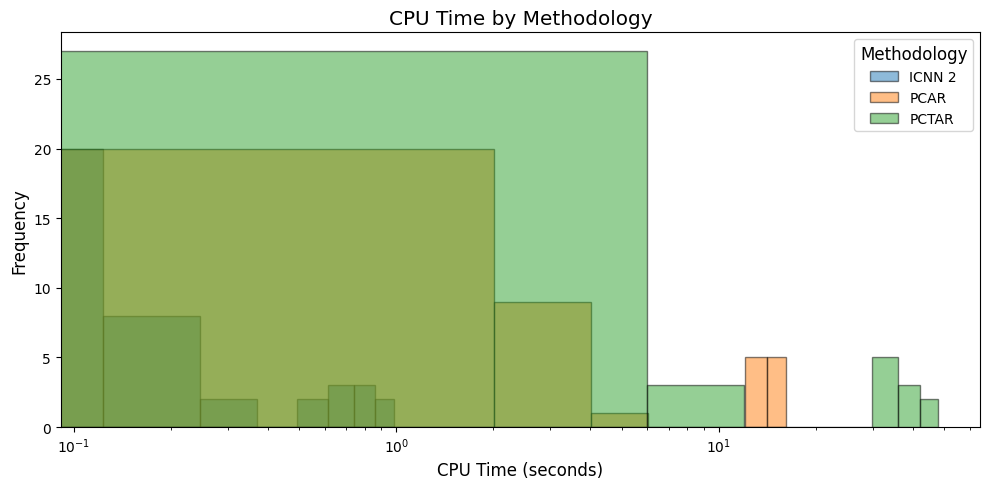

In [67]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"]
# Create a single figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histograms on the same axis with log scale for x-axis
for name, group in list(grouped_df)[-3: ]:
    n, bins, patches = ax.hist(group, bins=8, alpha=0.5, label=name, edgecolor='black')

ax.set_title('CPU Time by Methodology', fontsize="x-large")
ax.set_xlabel('CPU Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Add legend to differentiate methodologies
ax.legend(title="Methodology", fontsize="medium", title_fontsize="large")

plt.tight_layout()
plt.show()

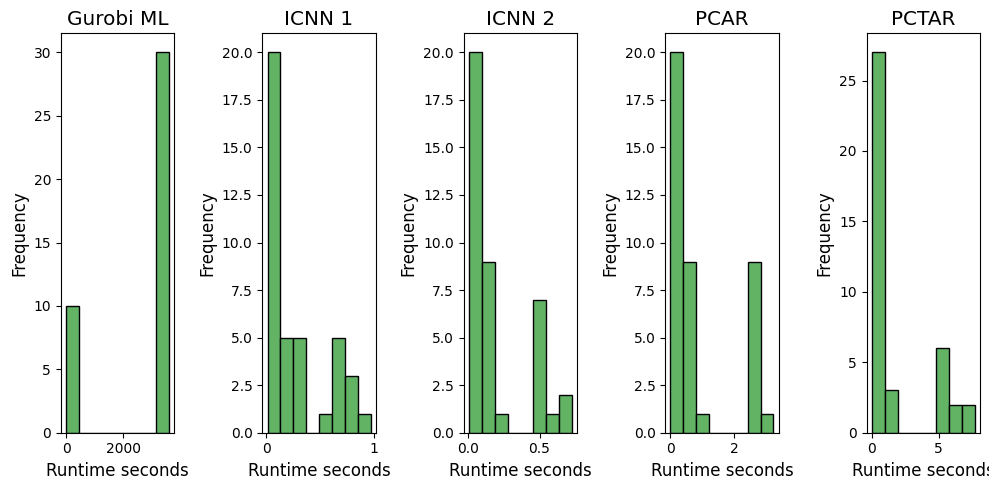

In [68]:
grouped_df = summary_tables.groupby("methodology")["runtime"]
fig, axes = plt.subplots(1, 5, figsize=(10, 5))  # 12 months, 3x4 grid
axes = axes.ravel()  # Flattening the axes array for easy indexing

for i, (name, group) in enumerate(grouped_df):
    n, bins, patches = axes[i].hist(group, bins=8, color='xkcd:boring green', edgecolor='black')
    
    # Get dynamic x-ticks
    max_bin = np.ceil(max(bins))
    min_bin = np.floor(min(bins))
    xticks = np.linspace(min_bin, max_bin, 4, dtype=float)
    axes[i].set_title(name, fontsize="x-large")
    axes[i].set_xlabel('Runtime seconds', fontsize="large")
    axes[i].set_ylabel('Frequency', fontsize="large")
    # axes[i].set_xticks(xticks)

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.savefig(os.path.join(cwd, "images", "runtime_histograms.png"))
plt.show()

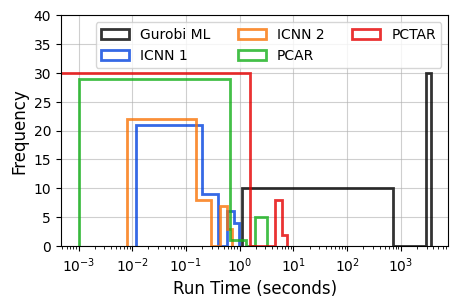

In [69]:
grouped_df = summary_tables.groupby("methodology")["runtime"]
fig, ax = plt.subplots(figsize=(5, 3))
colors =  xkcd_palette = ['xkcd:black', 'xkcd:blue', 'xkcd:orange', 'xkcd:green', 'xkcd:red', 'xkcd:purple', 'xkcd:grey']

# Plot histograms on the same axis with log scale for x-axis
for i, (name, group) in enumerate(list(grouped_df)):
    n, bins, patches = ax.hist(group, bins=5, alpha=0.8, label=name, edgecolor=colors[i % len(colors)], histtype="step", linewidth=2)

# ax.set_title('Run Time by Methodology', fontsize="x-large")
ax.set_xlabel('Run Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Set x and y axis lims
ax.set_ylim([0, 40])

# Add legend to differentiate methodologies
ax.legend(ncols=3, fontsize="medium", title_fontsize="large")

plt.grid(zorder=0, alpha=0.6)
plt.show()

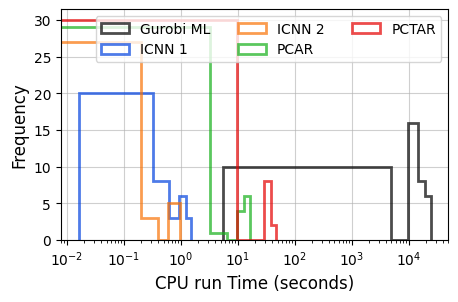

In [70]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"]
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['xkcd:black', 'xkcd:blue', 'xkcd:orange', 'xkcd:green', 'xkcd:red', 'xkcd:purple', 'xkcd:grey']

# Plot histograms on the same axis with log scale for x-axis
for i, (name, group) in enumerate(list(grouped_df)):
    n, bins, patches = ax.hist(group, bins=5, alpha=0.7, label=name, edgecolor=colors[i % len(colors)], histtype="step", linewidth=2)

# ax.set_title('Run Time by Methodology', fontsize="x-large")
ax.set_xlabel('CPU run Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Set x and y axis lims
# ax.set_ylim([0, 36])

# Add legend to differentiate methodologies
ax.legend(ncols = 3, fontsize="medium", title_fontsize="large")
plt.grid(zorder=0, alpha=0.6)
plt.show()